In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Data/diseases/Diseases_and_Symptoms_Data_Large.csv')

In [6]:
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [7]:
df.columns

Index(['diseases', 'anxiety and nervousness', 'depression',
       'shortness of breath', 'depressive or psychotic symptoms',
       'sharp chest pain', 'dizziness', 'insomnia',
       'abnormal involuntary movements', 'chest tightness',
       ...
       'stuttering or stammering', 'problems with orgasm', 'nose deformity',
       'lump over jaw', 'sore in nose', 'hip weakness', 'back swelling',
       'ankle stiffness or tightness', 'ankle weakness', 'neck weakness'],
      dtype='object', length=378)

In [8]:
X = df.drop('diseases', axis=1)
y = df['diseases']

In [9]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 377 entries, anxiety and nervousness to neck weakness
dtypes: int64(377)
memory usage: 710.3 MB


In [10]:
# converting data type 'int64' to 'int8' to reduce the memory usages
X = X.astype({col: "int8" for col in df.select_dtypes("int64").columns})

In [11]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 377 entries, anxiety and nervousness to neck weakness
dtypes: int8(377)
memory usage: 88.8 MB


In [12]:
y = y.str.lower()
y = y.str.strip()

### train test split

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [15]:
X_train.shape, X_test.shape

((172861, 377), (74084, 377))

In [16]:
/

()

In [17]:
# ros = RandomOverSampler(sampling_strategy="auto", random_state=42)
# X_train, y_train= ros.fit_resample(X_train, y_train)

In [18]:
X_train.shape, X_test.shape

((172861, 377), (74084, 377))

### Random Forest

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

In [20]:
model = RandomForestClassifier(n_estimators=150, max_depth=50, max_features='sqrt',
                               class_weight='balanced', random_state=42, min_samples_split=5,
                               min_samples_leaf=4, n_jobs=-1)

In [21]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=50,
                       min_samples_leaf=4, min_samples_split=5,
                       n_estimators=150, n_jobs=-1, random_state=42)

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [24]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.843056530424923
Precision: 0.8793192609476932
Recall: 0.843056530424923
F1-score: 0.8545552169836859


In [26]:
y_val_pred = model.predict(X_train)
accuracy = accuracy_score(y_train, y_val_pred)
print(accuracy)

0.8645385598833745


# check model is overfitted or not

as upper accuracy given our model is not overfitted because accuracy gap vary only 2-4% that means our model is not overfitted

In [27]:
model.score(X_test, y_test)

0.843056530424923

In [28]:
pickle.dump(model, open('/content/drive/MyDrive/final project/random_forest.pkl', 'wb'))

In [29]:
from joblib import dump, load

In [30]:
rf = load('/content/drive/MyDrive/final project/random_forest.pkl')

In [31]:
dump(rf, "/content/drive/MyDrive/final project/com_random_forest.pkl", compress=3)

['/content/drive/MyDrive/final project/com_random_forest.pkl']

In [43]:
symptom_list = [i for i in X_train.columns]

In [40]:
from joblib import dump, load

In [41]:
with open('/content/drive/MyDrive/final project/com_random_forest.pkl', 'rb') as p_model_file:
  p_model = load(p_model_file)

In [45]:
symptom_list

['anxiety and nervousness',
 'depression',
 'shortness of breath',
 'depressive or psychotic symptoms',
 'sharp chest pain',
 'dizziness',
 'insomnia',
 'abnormal involuntary movements',
 'chest tightness',
 'palpitations',
 'irregular heartbeat',
 'breathing fast',
 'hoarse voice',
 'sore throat',
 'difficulty speaking',
 'cough',
 'nasal congestion',
 'throat swelling',
 'diminished hearing',
 'lump in throat',
 'throat feels tight',
 'difficulty in swallowing',
 'skin swelling',
 'retention of urine',
 'groin mass',
 'leg pain',
 'hip pain',
 'suprapubic pain',
 'blood in stool',
 'lack of growth',
 'emotional symptoms',
 'elbow weakness',
 'back weakness',
 'pus in sputum',
 'symptoms of the scrotum and testes',
 'swelling of scrotum',
 'pain in testicles',
 'flatulence',
 'pus draining from ear',
 'jaundice',
 'mass in scrotum',
 'white discharge from eye',
 'irritable infant',
 'abusing alcohol',
 'fainting',
 'hostile behavior',
 'drug abuse',
 'sharp abdominal pain',
 'feeling 

In [46]:
# 3️⃣ Create a dictionary with all symptoms set to 0
user_input = {symptom: 0 for symptom in symptom_list}

# 4️⃣ Ask user to enter the symptoms they have
print("\n✅ Available Symptoms:", ", ".join(symptom_list))
selected_symptoms = input("\n🔹 Enter the symptoms you have (comma-separated): ").lower().split(",")

# 5️⃣ Update selected symptoms to 1
for symptom in selected_symptoms:
    symptom = symptom.strip()  # Remove spaces
    if symptom in user_input:
        user_input[symptom] = 1  # Mark as present
    else:
        print(f"⚠️ Warning: '{symptom}' is not a recognized symptom.")


✅ Available Symptoms: anxiety and nervousness, depression, shortness of breath, depressive or psychotic symptoms, sharp chest pain, dizziness, insomnia, abnormal involuntary movements, chest tightness, palpitations, irregular heartbeat, breathing fast, hoarse voice, sore throat, difficulty speaking, cough, nasal congestion, throat swelling, diminished hearing, lump in throat, throat feels tight, difficulty in swallowing, skin swelling, retention of urine, groin mass, leg pain, hip pain, suprapubic pain, blood in stool, lack of growth, emotional symptoms, elbow weakness, back weakness, pus in sputum, symptoms of the scrotum and testes, swelling of scrotum, pain in testicles, flatulence, pus draining from ear, jaundice, mass in scrotum, white discharge from eye, irritable infant, abusing alcohol, fainting, hostile behavior, drug abuse, sharp abdominal pain, feeling ill, vomiting, headache, nausea, diarrhea, vaginal itching, vaginal dryness, painful urination, involuntary urination, pain

In [47]:
input_data = pd.DataFrame([user_input])

In [48]:
input_data

,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,1,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
perdicted_disease = p_model.predict(input_data)

In [63]:
print(f"\n🔍 Based on the symptoms, the predicted disease is: **{perdicted_disease[0]}**")


🔍 Based on the symptoms, the predicted disease is: **wernicke korsakoff syndrome**


In [62]:
#Classification Report
class_report = classification_report(y_test, y_pred, output_dict=True)
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_


📊 Classification Report:
                                                           precision    recall  f1-score   support

                               abdominal aortic aneurysm       0.97      1.00      0.98        32
                                        abdominal hernia       0.94      0.96      0.95       115
                                         abscess of nose       0.77      0.88      0.82        90
                                     abscess of the lung       0.62      1.00      0.76         8
                                  abscess of the pharynx       0.97      0.88      0.92       103
                                    acanthosis nigricans       0.35      0.88      0.50         8
                                               acariasis       1.00      0.86      0.92         7
                                               achalasia       0.67      0.97      0.79        30
                                                    acne       0.70      0.79      0.74   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

In [59]:
y_prob = model.predict_proba(X_test)

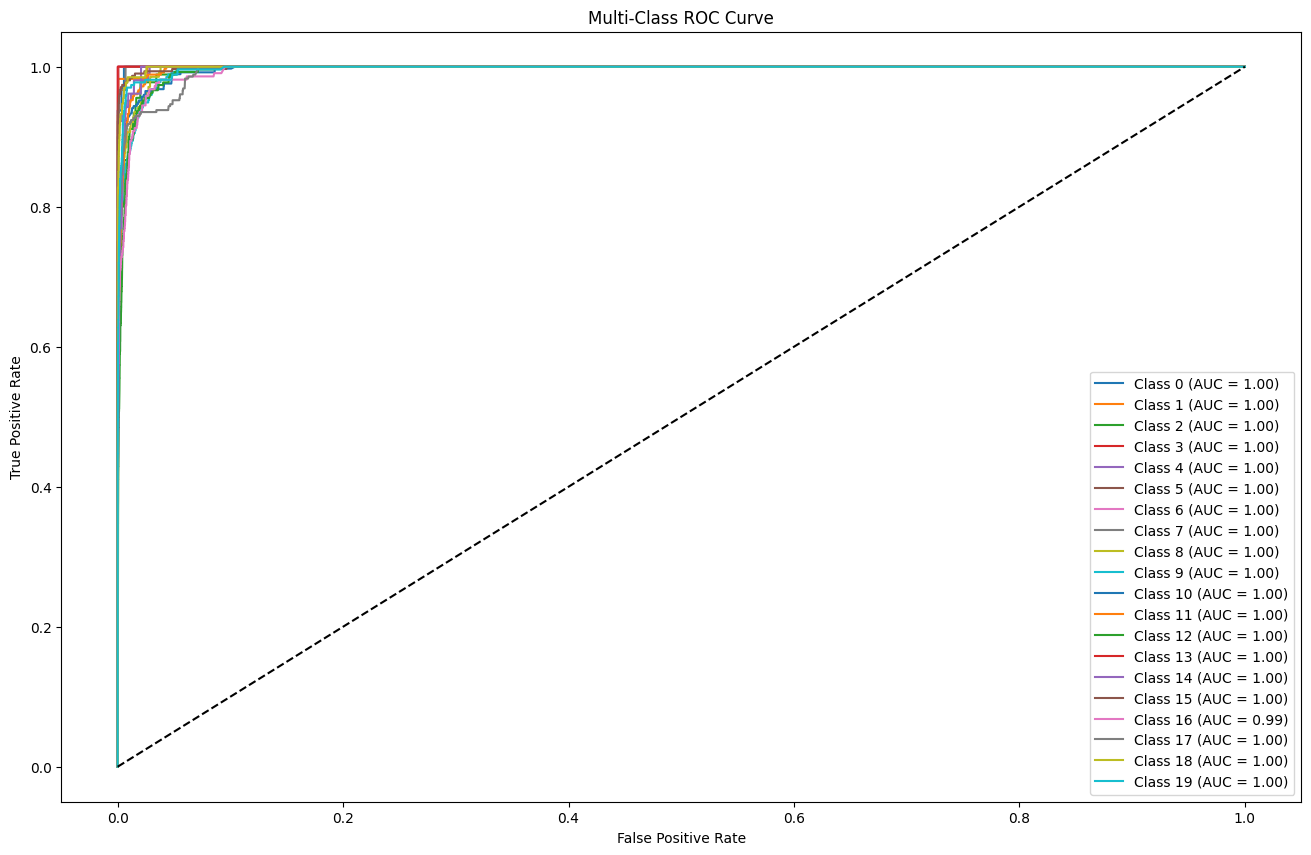

In [70]:
# ROC Curve (for multi-class classification)
n_classes = len(np.unique(y_test))
if n_classes > 2:
    plt.figure(figsize=(16, 10))
    for i in range(min(20, y_test_bin.shape[1])):  # Plot only 10 classes
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multi-Class ROC Curve")
    plt.legend()
    plt.savefig("roc_curve.png")
    plt.show()
